<a href="https://colab.research.google.com/github/keunsooyoon/Algorithms/blob/main/OnStructuralFormHodge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

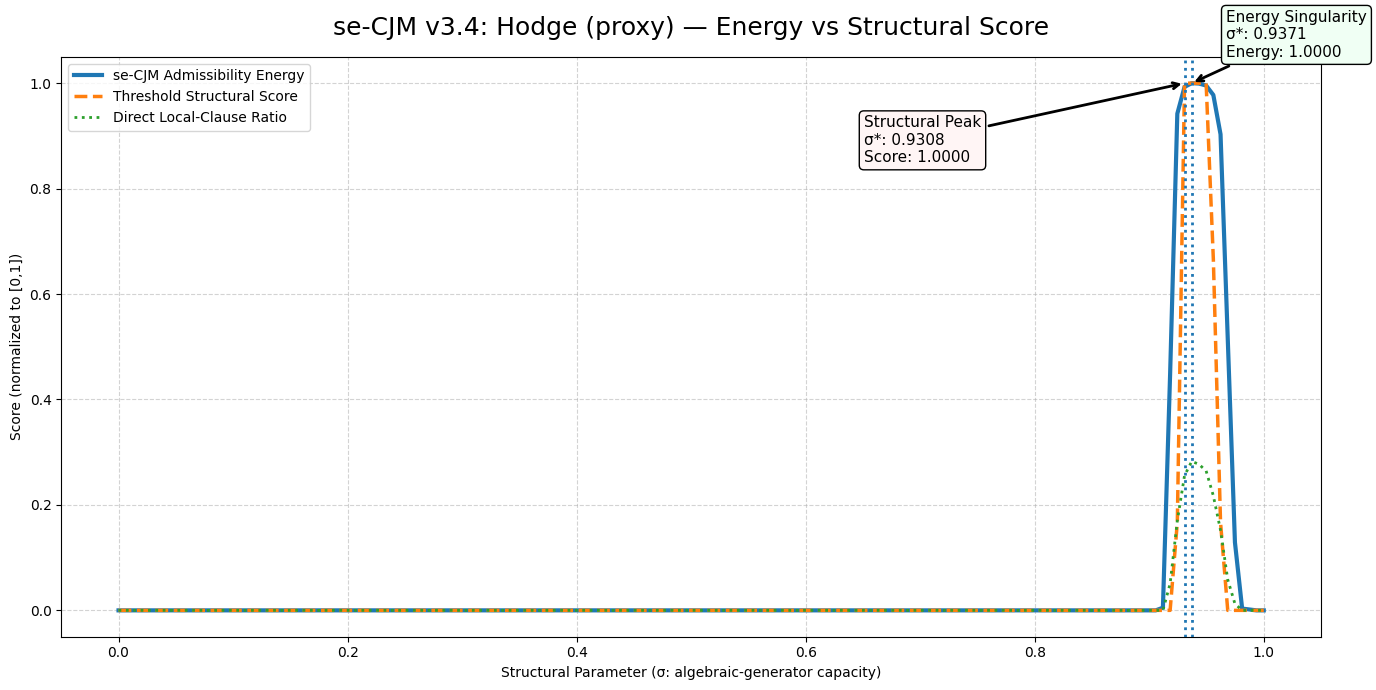

In [ ]:
# ============================================================
# Appendix 1: Python Code for Figure (se-CJM v3.4)
# ============================================================
# se-CJM (software-emulated CJM) implements a 4-step pipeline:
#   (1) Problem-specific embedding  -> logic-like literals (x1, x2)
#   (2) CJM core engine             -> sigma-wise admissibility energy
#   (3) Threshold structural check  -> local 3SAT-like clause truths
#                                      + threshold pass-rate (PySAT-free)
#   (4) Visualization               -> Energy vs SAT-score + peak callouts
#
# This lightweight version removes the PySAT dependency so that the
# figure can be executed immediately in minimal notebook environments.
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt

TINY = 1e-12


# ==========================================
# STEP 1: INPUT MODULE (Hodge proxy embedding)
# ==========================================
def step1_input_hodge_closure_proxy(
    sigma_range,
    t_vals,
    D=48,
    topo_dim=10,
    alg_min=6,
    alg_max=28,
    alpha=7.0,
    q=2.0,
    osc_amp=0.18,
    osc_period=220,
    noise=0.015,
    seed=1337,
):
    """
    Hodge proxy embedding (closure-proxy).
    Produces two literals x1, x2 on a (t, sigma) grid.

    Interpretation (proxy):
      - sigma represents "algebraic-generator capacity" (0..1)
      - closure "pressure" increases with sigma
      - a narrow high-sigma region exhibits structural bursts (singularity-like)

    Output:
      x1, x2 : {0,1} arrays with shape (len(t_vals), len(sigma_range))
    """
    rng = np.random.default_rng(seed)

    S, T = np.meshgrid(sigma_range, t_vals)  # rows=t, cols=sigma

    # Deterministic structure component: ramp + oscillation
    ramp = (S ** 2.2)
    osc = osc_amp * np.sin(2 * np.pi * T / osc_period) * (S ** 1.8)

    # "closure pressure" with mild noise
    base = ramp + osc + noise * rng.standard_normal(size=ramp.shape)

    # A "critical region" bias near high sigma to create a sharp structural zone
    critical = np.exp(-((S - 0.93) ** 2) / (2 * (0.04 ** 2)))
    score = base + 0.35 * critical

    # Nonlinear gate -> literals
    g = 1 / (1 + np.exp(-alpha * (score - np.median(score))))

    # x1: strongest events
    thr1 = np.quantile(g, 0.995)
    x1 = (g >= thr1).astype(np.uint8)

    # x2: sharpened companion
    g2 = g ** q
    thr2 = np.quantile(g2, 0.990)
    x2 = (g2 >= thr2).astype(np.uint8)

    return x1, x2


# ==========================================
# STEP 2: CJM CORE ENGINE (kept reusable)
# ==========================================
def step2_cjm_core_engine(x1, x2, gate="OR", beta=20.0, mode="logistic"):
    """
    Universal CJM core engine.

    A. 3-literal clause interaction (minimal coupling)
       clauses_i = f(x1_i, x2_i, x1_{i-1})
    B. sigma-wise admissibility density (mean over t)
    C. Contrast mapping -> normalized "energy" in [0,1]
    """
    x1_prev = np.roll(x1, shift=1, axis=0)
    x1_prev[0, :] = 0

    if gate == "MAJ":
        clauses = ((x1 + x2 + x1_prev) >= 2).astype(np.uint8)
    elif gate == "AND3":
        clauses = (x1 & x2 & x1_prev).astype(np.uint8)
    else:
        clauses = (x1 | x2 | x1_prev).astype(np.uint8)

    sat_density = clauses.mean(axis=0)

    if mode == "zscore":
        z = (sat_density - sat_density.mean()) / (sat_density.std() + TINY)
        energy = 1 / (1 + np.exp(-z))
    else:
        center = np.median(sat_density)
        energy = 1 / (1 + np.exp(-beta * (sat_density - center)))

    energy = (energy - energy.min()) / (energy.max() - energy.min() + TINY)
    return energy


# ==========================================
# 3SAT-like local clause builder
# ==========================================
def build_local_clause_truths_for_sigma_window(
    x1_col,
    x2_col,
    gate="OR",
    start=0,
    win=240,
):
    """
    Build local truth values for one sigma-window.

    Local clause:
      f_i = OR(x1_i, x2_i, x1_{i-1})   or   MAJ / AND3

    Returns:
      truths : list[int] with values in {0,1}
    """
    end = min(len(x1_col), start + win)
    N = end - start
    if N <= 2:
        return []

    truths = []

    for i in range(N):
        a = int(x1_col[start + i])
        b = int(x2_col[start + i])

        if i == 0:
            p = int(x1_col[start - 1]) if start - 1 >= 0 else 0
        else:
            p = int(x1_col[start + i - 1])

        if gate == "MAJ":
            val = 1 if (a + b + p) >= 2 else 0
        elif gate == "AND3":
            val = 1 if (a & b & p) == 1 else 0
        else:
            val = 1 if (a | b | p) == 1 else 0

        truths.append(val)

    return truths


# ==========================================
# STEP 3: Threshold structural pass-rate
# ==========================================
def structural_score_per_sigma_threshold(
    x1,
    x2,
    gate="OR",
    win=240,
    stride=240,
    max_windows=6,
    theta=0.20,
):
    """
    For each sigma column, evaluate multiple windows and compute:

      structural_score(sigma)
        = (# windows with local_truth_ratio >= theta) / (# windows tested)

    This is a PySAT-free replacement for quick execution.

    Also returns:
      direct_rate(sigma) = average local clause truth ratio across windows

    Interpretation:
      - structural_score: threshold pass-rate
      - direct_rate: mean clause truth density
    """
    Tn, Sn = x1.shape
    starts = list(range(0, Tn, stride))[:max_windows]

    structural_score = np.zeros(Sn, dtype=np.float64)
    direct_rate = np.zeros(Sn, dtype=np.float64)

    for j in range(Sn):
        x1_col = x1[:, j]
        x2_col = x2[:, j]

        pass_count = 0
        tested = 0
        direct_scores = []

        for start in starts:
            truths = build_local_clause_truths_for_sigma_window(
                x1_col, x2_col, gate=gate, start=start, win=win
            )

            if len(truths) == 0:
                local_truth_ratio = 1.0
            else:
                local_truth_ratio = float(np.mean(truths))

            direct_scores.append(local_truth_ratio)
            tested += 1

            if local_truth_ratio >= theta:
                pass_count += 1

        structural_score[j] = pass_count / max(1, tested)
        direct_rate[j] = float(np.mean(direct_scores)) if direct_scores else 1.0

    return np.clip(structural_score, 0.0, 1.0), np.clip(direct_rate, 0.0, 1.0)


# ==========================================
# STEP 4: Plot (Energy vs structural score) + callouts
# ==========================================
def plot_energy_vs_sat_with_callouts(x_axis, energy, sat_score, direct_score, title):
    plt.figure(figsize=(14, 7), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    # curves
    plt.plot(x_axis, energy, linewidth=3, label="se-CJM Admissibility Energy")
    plt.plot(x_axis, sat_score, linewidth=2.5, linestyle="--", label="Threshold Structural Score")
    plt.plot(x_axis, direct_score, linewidth=2.0, linestyle=":", label="Direct Local-Clause Ratio")

    # peaks
    iE = int(np.argmax(energy))
    iS = int(np.argmax(sat_score))

    xE, yE = float(x_axis[iE]), float(energy[iE])
    xS, yS = float(x_axis[iS]), float(sat_score[iS])

    # markers
    plt.axvline(xE, linestyle=":", linewidth=2)
    plt.axvline(xS, linestyle=":", linewidth=2)

    # Energy callout
    plt.annotate(
        f"Energy Singularity\nσ*: {xE:.4f}\nEnergy: {yE:.4f}",
        xy=(xE, yE),
        xytext=(xE + 0.03 * (x_axis[-1] - x_axis[0]), min(1.05, yE + 0.35)),
        arrowprops=dict(arrowstyle="->", lw=2),
        bbox=dict(boxstyle="round", fc="#F0FFF4", ec="black"),
        fontsize=11,
    )

    # Structural-score callout
    plt.annotate(
        f"Structural Peak\nσ*: {xS:.4f}\nScore: {yS:.4f}",
        xy=(xS, yS),
        xytext=(xS - 0.28 * (x_axis[-1] - x_axis[0]), min(0.85, yS + 0.35)),
        arrowprops=dict(arrowstyle="->", lw=2),
        bbox=dict(boxstyle="round", fc="#FFF5F5", ec="black"),
        fontsize=11,
    )

    plt.title(title, fontsize=18, pad=16)
    plt.xlabel("Structural Parameter (σ: algebraic-generator capacity)")
    plt.ylabel("Score (normalized to [0,1])")
    plt.grid(linestyle="--", alpha=0.55)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================
# MASTER CONTROL (se-CJM v3.4)
# ==========================================
def run_seCJM_v34_lite_hodge_threshold():
    """
    Runs the se-CJM v3.4-lite pipeline:
      1) Hodge proxy embedding -> x1, x2
      2) CJM energy(sigma)
      3) threshold structural check (PySAT-free)
      4) plot Energy vs structural score with peak callouts

    Recommended quick stress test:
      - try theta = 0.90
      - try theta = 0.98
      - compare structural_score vs direct local-clause ratio
    """
    SIGMA_SPACE = np.linspace(0.0, 1.0, 160)
    T_SPACE = np.arange(0, 6000)

    # STEP 1
    x1, x2 = step1_input_hodge_closure_proxy(
        SIGMA_SPACE,
        T_SPACE,
        alpha=7.0,
        q=2.0,
        seed=1337
    )

    # STEP 2
    energy = step2_cjm_core_engine(x1, x2, gate="OR", beta=20.0, mode="logistic")

    # STEP 3
    sat_score, direct_score = structural_score_per_sigma_threshold(
        x1, x2,
        gate="OR",
        win=240,
        stride=240,
        max_windows=6,
        theta=0.20
    )

    # STEP 4
    plot_energy_vs_sat_with_callouts(
        SIGMA_SPACE,
        energy,
        sat_score,
        direct_score,
        "se-CJM v3.4: Hodge (proxy) — Energy vs Structural Score"
    )


# Execution
run_seCJM_v34_lite_hodge_threshold()

In [ ]:
# ============================================================
# Appendix 2: Conceptual Pseudocode for Hodge Filter
# ============================================================
# This appendix provides conceptual pseudocode (not executable Python)
# for the CJM-Hodge Filter. The purpose is not numerical implementation,
# but structural screening of an encoded instance before deeper CJM stages.
#
# The Hodge Filter is treated as a preprocessing-style admissibility gate:
#   (1) Structural lift           -> encoded object Sigma
#   (2) Closure screening         -> global closure consistency
#   (3) Coherence screening       -> structural/topological alignment
#   (4) Stability screening       -> perturbation robustness
#   (5) Singularity penalty       -> concentrated structural stress
#   (6) Hodge decision            -> PASS / BORDERLINE / REJECT
#
# In recursive CJM usage, the input may be:
#   - a real-world problem Phi
#   - a SAT-reduced instance F
#   - or an already encoded structural object Sigma
# ============================================================

DEFINE TINY_THRESHOLD = small positive constant
DEFINE TAU_HIGH = high admissibility threshold
DEFINE TAU_LOW  = low admissibility threshold


# ==========================================
# STEP 1: INPUT MODULE (structural lift)
# ==========================================
PROCEDURE step1_input_hodge_filter(input_instance):

    # Interpret input according to its current form
    IF input_instance is RealWorldProblem Phi:
        F <- ReduceToSAT(Phi)
        Sigma <- LiftToStructuralRepresentation(F)

    ELSE IF input_instance is SATReducedInstance F:
        Sigma <- LiftToStructuralRepresentation(F)

    ELSE:
        Sigma <- input_instance

    # Preserve only admissibility-relevant invariants
    Preserve:
        - topology
        - dimensional consistency
        - relational symmetry
        - clause/variable coupling structure

    RETURN Sigma


# ==========================================
# STEP 2: CLOSURE SCREENING
# ==========================================
PROCEDURE step2_closure_screening(Sigma):

    # Measure whether local fragments can be assembled
    # into a globally admissible structural form
    closure_score <- MeasureGlobalClosure(Sigma)

    RETURN closure_score


# ==========================================
# STEP 3: COHERENCE SCREENING
# ==========================================
PROCEDURE step3_coherence_screening(Sigma):

    # Measure whether internal relations remain aligned
    # across the encoded structural object
    coherence_score <- MeasureTopologicalCoherence(Sigma)

    Check for:
        - disconnected constraint islands
        - polarity imbalance
        - broken global alignment
        - excessive local contradiction concentration

    RETURN coherence_score


# ==========================================
# STEP 4: STABILITY SCREENING
# ==========================================
PROCEDURE step4_stability_screening(Sigma):

    # Apply small admissible perturbations and evaluate robustness
    perturbation_set <- GenerateAdmissiblePerturbations(Sigma)

    stability_accumulator <- 0
    perturbation_count <- 0

    FOR each deltaSigma in perturbation_set:
        local_stability <- MeasureRobustness(Sigma, deltaSigma)
        stability_accumulator <- stability_accumulator + local_stability
        perturbation_count <- perturbation_count + 1
    END FOR

    stability_score <- stability_accumulator / max(1, perturbation_count)

    RETURN stability_score


# ==========================================
# STEP 5: SINGULARITY PENALTY
# ==========================================
PROCEDURE step5_singularity_penalty(Sigma):

    # Detect whether contradiction, curvature, or structural stress
    # is excessively concentrated in narrow subregions
    singularity_penalty <- DetectStructuralSingularity(Sigma)

    Examples:
        - one variable dominates too many clauses
        - contradiction collapses into narrow hubs
        - local stress sharply exceeds global average

    RETURN singularity_penalty


# ==========================================
# STEP 6: HODGE FILTER DECISION
# ==========================================
PROCEDURE step6_hodge_filter_decision(
    closure_score,
    coherence_score,
    stability_score,
    singularity_penalty
):

    # Aggregate admissibility into one Hodge score
    HodgeScore <-
          w1 * closure_score
        + w2 * coherence_score
        + w3 * stability_score
        - w4 * singularity_penalty

    # Final filter decision
    IF HodgeScore >= TAU_HIGH:
        verdict <- PASS

    ELSE IF HodgeScore >= TAU_LOW:
        verdict <- BORDERLINE

    ELSE:
        verdict <- REJECT
    END IF

    RETURN verdict, HodgeScore


# ==========================================
# MASTER CONTROL (CJM-Hodge Filter)
# ==========================================
PROCEDURE run_CJM_Hodge_Filter(input_instance):

    # STEP 1
    Sigma <- step1_input_hodge_filter(input_instance)

    # STEP 2
    closure_score <- step2_closure_screening(Sigma)

    # STEP 3
    coherence_score <- step3_coherence_screening(Sigma)

    # STEP 4
    stability_score <- step4_stability_screening(Sigma)

    # STEP 5
    singularity_penalty <- step5_singularity_penalty(Sigma)

    # STEP 6
    verdict, HodgeScore <- step6_hodge_filter_decision(
        closure_score,
        coherence_score,
        stability_score,
        singularity_penalty
    )

    # Output to deeper CJM stages
    IF verdict == PASS:
        ForwardToDeeperCJM(Sigma)

    ELSE IF verdict == BORDERLINE:
        FlagForReencodingOrAuxiliaryReview(Sigma)

    ELSE:
        RejectAsStructurallyInadmissible(Sigma)
    END IF

    RETURN
        verdict,
        HodgeScore,
        closure_score,
        coherence_score,
        stability_score,
        singularity_penalty

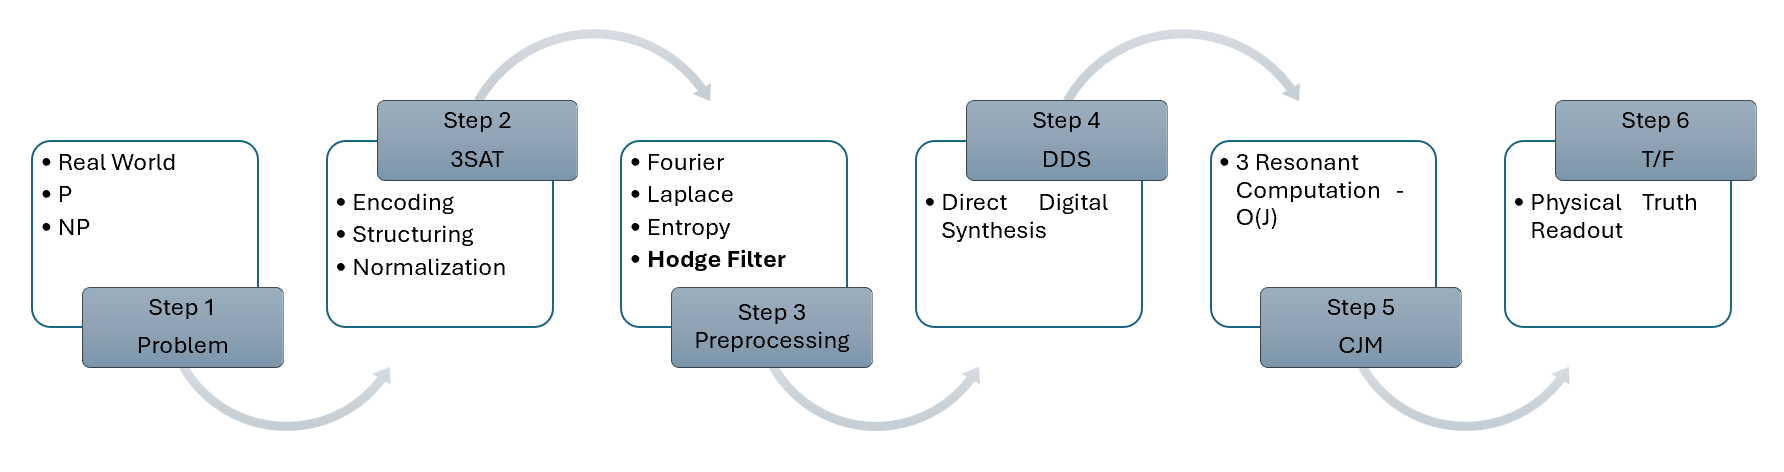

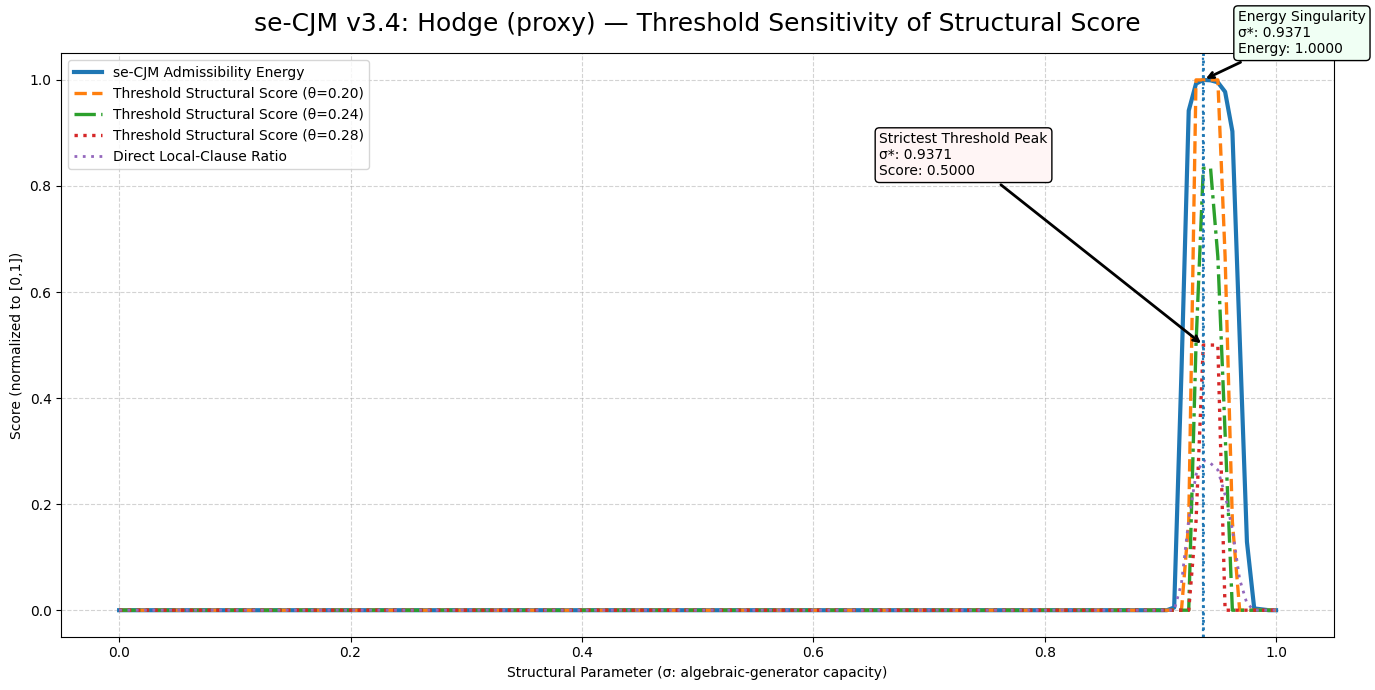

In [2]:
# ============================================================
# Appendix 3: Python Code for Threshold Sensitivity Figure (se-CJM v3.4)
# ============================================================
# se-CJM (software-emulated CJM) implements a 4-step pipeline:
#   (1) Problem-specific embedding  -> logic-like literals (x1, x2)
#   (2) CJM core engine             -> sigma-wise admissibility energy
#   (3) Threshold structural check  -> local 3SAT-like clause truths
#                                      + threshold pass-rate (PySAT-free)
#   (4) Visualization               -> theta-sensitivity comparison
#
# This appendix reuses the same Hodge proxy pipeline as Appendix 1,
# but compares multiple threshold values theta in a unified figure.
# The purpose is to illustrate how stricter thresholds narrow the
# admissible band while sharpening structural discrimination.
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt

TINY = 1e-12


# ==========================================
# STEP 1: INPUT MODULE (Hodge proxy embedding)
# ==========================================
def step1_input_hodge_closure_proxy(
    sigma_range,
    t_vals,
    D=48,
    topo_dim=10,
    alg_min=6,
    alg_max=28,
    alpha=7.0,
    q=2.0,
    osc_amp=0.18,
    osc_period=220,
    noise=0.015,
    seed=1337,
):
    """
    Hodge proxy embedding (closure-proxy).
    Produces two literals x1, x2 on a (t, sigma) grid.

    Interpretation (proxy):
      - sigma represents "algebraic-generator capacity" (0..1)
      - closure "pressure" increases with sigma
      - a narrow high-sigma region exhibits structural bursts (singularity-like)

    Output:
      x1, x2 : {0,1} arrays with shape (len(t_vals), len(sigma_range))
    """
    rng = np.random.default_rng(seed)

    S, T = np.meshgrid(sigma_range, t_vals)  # rows=t, cols=sigma

    # Deterministic structure component: ramp + oscillation
    ramp = (S ** 2.2)
    osc = osc_amp * np.sin(2 * np.pi * T / osc_period) * (S ** 1.8)

    # "closure pressure" with mild noise
    base = ramp + osc + noise * rng.standard_normal(size=ramp.shape)

    # A "critical region" bias near high sigma to create a sharp structural zone
    critical = np.exp(-((S - 0.93) ** 2) / (2 * (0.04 ** 2)))
    score = base + 0.35 * critical

    # Nonlinear gate -> literals
    g = 1 / (1 + np.exp(-alpha * (score - np.median(score))))

    # x1: strongest events
    thr1 = np.quantile(g, 0.995)
    x1 = (g >= thr1).astype(np.uint8)

    # x2: sharpened companion
    g2 = g ** q
    thr2 = np.quantile(g2, 0.990)
    x2 = (g2 >= thr2).astype(np.uint8)

    return x1, x2


# ==========================================
# STEP 2: CJM CORE ENGINE (kept reusable)
# ==========================================
def step2_cjm_core_engine(x1, x2, gate="OR", beta=20.0, mode="logistic"):
    """
    Universal CJM core engine.

    A. 3-literal clause interaction (minimal coupling)
       clauses_i = f(x1_i, x2_i, x1_{i-1})
    B. sigma-wise admissibility density (mean over t)
    C. Contrast mapping -> normalized "energy" in [0,1]
    """
    x1_prev = np.roll(x1, shift=1, axis=0)
    x1_prev[0, :] = 0

    if gate == "MAJ":
        clauses = ((x1 + x2 + x1_prev) >= 2).astype(np.uint8)
    elif gate == "AND3":
        clauses = (x1 & x2 & x1_prev).astype(np.uint8)
    else:
        clauses = (x1 | x2 | x1_prev).astype(np.uint8)

    sat_density = clauses.mean(axis=0)

    if mode == "zscore":
        z = (sat_density - sat_density.mean()) / (sat_density.std() + TINY)
        energy = 1 / (1 + np.exp(-z))
    else:
        center = np.median(sat_density)
        energy = 1 / (1 + np.exp(-beta * (sat_density - center)))

    energy = (energy - energy.min()) / (energy.max() - energy.min() + TINY)
    return energy


# ==========================================
# 3SAT-like local clause builder
# ==========================================
def build_local_clause_truths_for_sigma_window(
    x1_col,
    x2_col,
    gate="OR",
    start=0,
    win=240,
):
    """
    Build local truth values for one sigma-window.

    Local clause:
      f_i = OR(x1_i, x2_i, x1_{i-1})   or   MAJ / AND3

    Returns:
      truths : list[int] with values in {0,1}
    """
    end = min(len(x1_col), start + win)
    N = end - start
    if N <= 2:
        return []

    truths = []

    for i in range(N):
        a = int(x1_col[start + i])
        b = int(x2_col[start + i])

        if i == 0:
            p = int(x1_col[start - 1]) if start - 1 >= 0 else 0
        else:
            p = int(x1_col[start + i - 1])

        if gate == "MAJ":
            val = 1 if (a + b + p) >= 2 else 0
        elif gate == "AND3":
            val = 1 if (a & b & p) == 1 else 0
        else:
            val = 1 if (a | b | p) == 1 else 0

        truths.append(val)

    return truths


# ==========================================
# STEP 3: Threshold structural pass-rate
# ==========================================
def structural_score_per_sigma_threshold(
    x1,
    x2,
    gate="OR",
    win=240,
    stride=240,
    max_windows=6,
    theta=0.20,
):
    """
    For each sigma column, evaluate multiple windows and compute:

      structural_score(sigma)
        = (# windows with local_truth_ratio >= theta) / (# windows tested)

    This is a PySAT-free replacement for quick execution.

    Also returns:
      direct_rate(sigma) = average local clause truth ratio across windows

    Interpretation:
      - structural_score: threshold pass-rate
      - direct_rate: mean clause truth density
    """
    Tn, Sn = x1.shape
    starts = list(range(0, Tn, stride))[:max_windows]

    structural_score = np.zeros(Sn, dtype=np.float64)
    direct_rate = np.zeros(Sn, dtype=np.float64)

    for j in range(Sn):
        x1_col = x1[:, j]
        x2_col = x2[:, j]

        pass_count = 0
        tested = 0
        direct_scores = []

        for start in starts:
            truths = build_local_clause_truths_for_sigma_window(
                x1_col, x2_col, gate=gate, start=start, win=win
            )

            if len(truths) == 0:
                local_truth_ratio = 1.0
            else:
                local_truth_ratio = float(np.mean(truths))

            direct_scores.append(local_truth_ratio)
            tested += 1

            if local_truth_ratio >= theta:
                pass_count += 1

        structural_score[j] = pass_count / max(1, tested)
        direct_rate[j] = float(np.mean(direct_scores)) if direct_scores else 1.0

    return np.clip(structural_score, 0.0, 1.0), np.clip(direct_rate, 0.0, 1.0)


# ==========================================
# STEP 4: Plot (theta sensitivity comparison)
# ==========================================
def plot_theta_sensitivity_comparison(
    x_axis,
    energy,
    theta_scores,
    direct_score,
    theta_list,
    title,
):
    plt.figure(figsize=(14, 7), facecolor="white")
    ax = plt.gca()
    ax.set_facecolor("white")

    # Base energy curve
    plt.plot(x_axis, energy, linewidth=3, label="se-CJM Admissibility Energy")

    # Threshold curves
    styles = ["--", "-.", ":"]
    for k, theta in enumerate(theta_list):
        curve = theta_scores[k]
        plt.plot(
            x_axis,
            curve,
            linewidth=2.4,
            linestyle=styles[k % len(styles)],
            label=f"Threshold Structural Score (θ={theta:.2f})"
        )

    # Direct local-clause ratio
    plt.plot(
        x_axis,
        direct_score,
        linewidth=2.0,
        linestyle=(0, (1, 2)),
        label="Direct Local-Clause Ratio"
    )

    # Energy peak
    iE = int(np.argmax(energy))
    xE, yE = float(x_axis[iE]), float(energy[iE])
    plt.axvline(xE, linestyle=":", linewidth=2)
    plt.annotate(
        f"Energy Singularity\nσ*: {xE:.4f}\nEnergy: {yE:.4f}",
        xy=(xE, yE),
        xytext=(xE + 0.03 * (x_axis[-1] - x_axis[0]), min(1.05, yE + 0.32)),
        arrowprops=dict(arrowstyle="->", lw=2),
        bbox=dict(boxstyle="round", fc="#F0FFF4", ec="black"),
        fontsize=10,
    )

    # Peak callout for strictest threshold
    strict_idx = len(theta_list) - 1
    strict_curve = theta_scores[strict_idx]
    iS = int(np.argmax(strict_curve))
    xS, yS = float(x_axis[iS]), float(strict_curve[iS])
    plt.axvline(xS, linestyle=":", linewidth=1.6)

    plt.annotate(
        f"Strictest Threshold Peak\nσ*: {xS:.4f}\nScore: {yS:.4f}",
        xy=(xS, yS),
        xytext=(xS - 0.28 * (x_axis[-1] - x_axis[0]), min(0.85, yS + 0.32)),
        arrowprops=dict(arrowstyle="->", lw=2),
        bbox=dict(boxstyle="round", fc="#FFF5F5", ec="black"),
        fontsize=10,
    )

    plt.title(title, fontsize=18, pad=16)
    plt.xlabel("Structural Parameter (σ: algebraic-generator capacity)")
    plt.ylabel("Score (normalized to [0,1])")
    plt.grid(linestyle="--", alpha=0.55)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================
# MASTER CONTROL (se-CJM v3.4-theta)
# ==========================================
def run_seCJM_v34_hodge_theta_sensitivity():
    """
    Runs the se-CJM v3.4 threshold-sensitivity pipeline:
      1) Hodge proxy embedding -> x1, x2
      2) CJM energy(sigma)
      3) threshold structural check for multiple theta values
      4) plot theta-sensitivity comparison in one figure

    Recommended comparison:
      - theta = 0.20
      - theta = 0.24
      - theta = 0.28
    """
    SIGMA_SPACE = np.linspace(0.0, 1.0, 160)
    T_SPACE = np.arange(0, 6000)
    THETA_LIST = [0.20, 0.24, 0.28]

    # STEP 1
    x1, x2 = step1_input_hodge_closure_proxy(
        SIGMA_SPACE,
        T_SPACE,
        alpha=7.0,
        q=2.0,
        seed=1337
    )

    # STEP 2
    energy = step2_cjm_core_engine(
        x1, x2, gate="OR", beta=20.0, mode="logistic"
    )

    # STEP 3
    theta_scores = []
    direct_score = None

    for theta in THETA_LIST:
        sat_score, direct_tmp = structural_score_per_sigma_threshold(
            x1, x2,
            gate="OR",
            win=240,
            stride=240,
            max_windows=6,
            theta=theta
        )
        theta_scores.append(sat_score)

        # Direct local-clause ratio is theta-independent;
        # keep the first one only
        if direct_score is None:
            direct_score = direct_tmp

    # STEP 4
    plot_theta_sensitivity_comparison(
        SIGMA_SPACE,
        energy,
        theta_scores,
        direct_score,
        THETA_LIST,
        "se-CJM v3.4: Hodge (proxy) — Threshold Sensitivity of Structural Score"
    )


# Execution
run_seCJM_v34_hodge_theta_sensitivity()